# 📘 Loan Default Prediction - Train & Save Models

In [1]:
# Step 1: Import Libraries
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC
from xgboost import XGBClassifier
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report
import matplotlib.pyplot as plt
import seaborn as sns
import pickle
import time

from sklearn.metrics import roc_auc_score, roc_curve
import matplotlib.pyplot as plt


In [15]:
!pip install scikit-learn==1.2.2



     ---------------------------------------- 0.0/7.3 MB ? eta -:--:--
     ------------ --------------------------- 2.4/7.3 MB 12.7 MB/s eta 0:00:01
     ---------------------------- ----------- 5.2/7.3 MB 13.5 MB/s eta 0:00:01
     ---------------------------------------- 7.3/7.3 MB 13.1 MB/s eta 0:00:00
  Installing build dependencies: started
  Installing build dependencies: finished with status 'done'
  Getting requirements to build wheel: started
  Getting requirements to build wheel: finished with status 'done'
  Preparing metadata (pyproject.toml): started
  Preparing metadata (pyproject.toml): finished with status 'error'


  error: subprocess-exited-with-error
  
  × Preparing metadata (pyproject.toml) did not run successfully.
  │ exit code: 1
  ╰─> [45 lines of output]
      Partial import of sklearn during the build process.
      Traceback (most recent call last):
        File "C:\Users\MOHIT S GAHLOT\AppData\Local\Programs\Python\Python313\Lib\site-packages\pip\_vendor\pyproject_hooks\_in_process\_in_process.py", line 353, in <module>
          main()
          ~~~~^^
        File "C:\Users\MOHIT S GAHLOT\AppData\Local\Programs\Python\Python313\Lib\site-packages\pip\_vendor\pyproject_hooks\_in_process\_in_process.py", line 335, in main
          json_out['return_val'] = hook(**hook_input['kwargs'])
                                   ~~~~^^^^^^^^^^^^^^^^^^^^^^^^
        File "C:\Users\MOHIT S GAHLOT\AppData\Local\Programs\Python\Python313\Lib\site-packages\pip\_vendor\pyproject_hooks\_in_process\_in_process.py", line 149, in prepare_metadata_for_build_wheel
          return hook(metadata_directory, c

In [2]:
# Step 2: Load Data
df = pd.read_csv('Loan_default.csv')
df = df.dropna()
df.head()


,LoanID,Age,Income,LoanAmount,CreditScore,MonthsEmployed,NumCreditLines,InterestRate,LoanTerm,DTIRatio,Education,EmploymentType,MaritalStatus,HasMortgage,HasDependents,loan_purpose,HasCoSigner,default_status
0,I38PQUQS96,56,85994,50587,520,80,4,15.23,36,0.44,Bachelor's,Full-time,Divorced,Yes,Yes,Other,Yes,0
1,HPSK72WA7R,69,50432,124440,458,15,1,4.81,60,0.68,Master's,Full-time,Married,No,No,Other,Yes,0
2,C1OZ6DPJ8Y,46,84208,129188,451,26,3,21.17,24,0.31,Master's,Unemployed,Divorced,Yes,Yes,Auto,No,1
3,V2KKSFM3UN,32,31713,44799,743,0,3,7.07,24,0.23,High School,Full-time,Married,No,No,Business,No,0
4,EY08JDHTZP,60,20437,9139,633,8,4,6.51,48,0.73,Bachelor's,Unemployed,Divorced,No,Yes,Auto,No,0


In [3]:
# Step 3: Encode Categorical Columns
le_dict = {}
for col in df.columns:
    if df[col].dtype == 'object':
        le = LabelEncoder()
        df[col] = le.fit_transform(df[col])
        le_dict[col] = le

In [4]:
# Step 4: Prepare Data

X = df.drop('default_status', axis=1)
y = df['default_status']
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)


# end------------------------------------------------------------------------------------------

In [9]:
# Step 5: Train Models
# Train Random Forest and measure time
start_rf = time.time()
rf = RandomForestClassifier()
rf.fit(X_train, y_train)
end_rf = time.time()
rf_time = end_rf - start_rf

print(f"Random Forest Training Time: {rf_time:.2f} seconds")


Random Forest Training Time: 64.98 seconds


In [ ]:

# Train SVM and measure time
start_svm = time.time()
svm = SVC(probability=True)
svm.fit(X_train, y_train)
end_svm = time.time()
svm_time = end_svm - start_svm


print(f"SVM Training Time: {svm_time:.2f} seconds")


SVM Training Time: 8965.17 seconds


In [13]:
# Train XGBoost and measure time
start_xgb = time.time()
xgb = XGBClassifier(use_label_encoder=False, eval_metric='logloss')
xgb.fit(X_train, y_train)
end_xgb = time.time()
xgb_time = end_xgb - start_xgb


print(f"XGBoost Training Time: {xgb_time:.2f} seconds")


c:\Users\MOHIT S GAHLOT\AppData\Local\Programs\Python\Python313\Lib\site-packages\xgboost\core.py:158: UserWarning: [02:31:44] WARNING: C:\buildkite-agent\builds\buildkite-windows-cpu-autoscaling-group-i-08cbc0333d8d4aae1-1\xgboost\xgboost-ci-windows\src\learner.cc:740: 
Parameters: { "use_label_encoder" } are not used.

  warnings.warn(smsg, UserWarning)


XGBoost Training Time: 2.33 seconds


✅ Models and encoders loaded successfully!
Random Forest Accuracy: 0.89
              precision    recall  f1-score   support

           0       0.89      1.00      0.94     45170
           1       0.66      0.04      0.08      5900

    accuracy                           0.89     51070
   macro avg       0.77      0.52      0.51     51070
weighted avg       0.86      0.89      0.84     51070



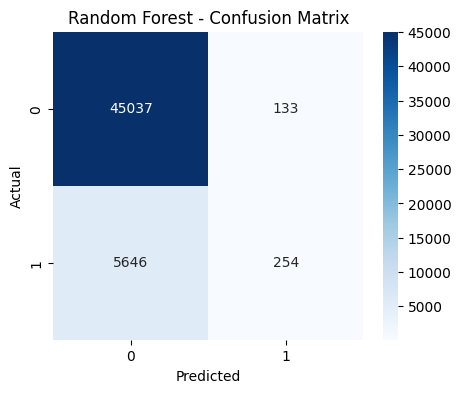

SVM Accuracy: 0.88
              precision    recall  f1-score   support

           0       0.88      1.00      0.94     45170
           1       0.00      0.00      0.00      5900

    accuracy                           0.88     51070
   macro avg       0.44      0.50      0.47     51070
weighted avg       0.78      0.88      0.83     51070



c:\Users\MOHIT S GAHLOT\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\metrics\_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
c:\Users\MOHIT S GAHLOT\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\metrics\_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
c:\Users\MOHIT S GAHLOT\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\metrics\_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavi

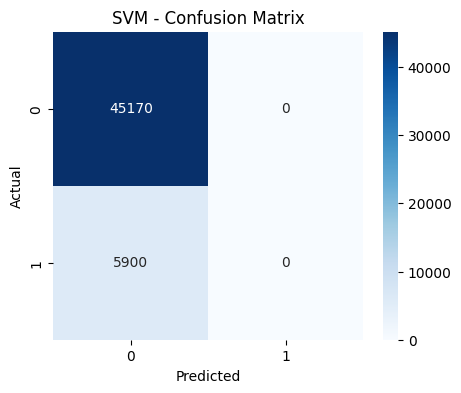

XGBoost Accuracy: 0.89
              precision    recall  f1-score   support

           0       0.89      0.99      0.94     45170
           1       0.54      0.08      0.14      5900

    accuracy                           0.89     51070
   macro avg       0.71      0.54      0.54     51070
weighted avg       0.85      0.89      0.85     51070



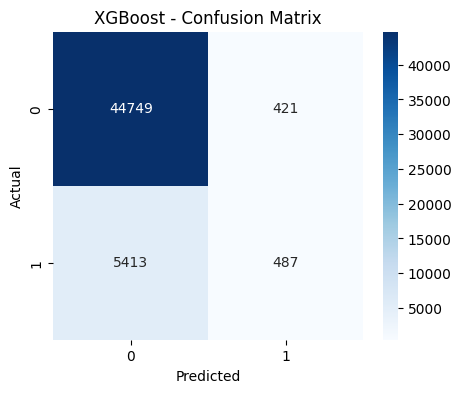

In [5]:
# Load the models
with open('rf_model.pkl', 'rb') as f:
    rf = pickle.load(f)

with open('svm_model.pkl', 'rb') as f:
    svm = pickle.load(f)

with open('xgb_model.pkl', 'rb') as f:
    xgb = pickle.load(f)

# Load the label encoders
with open('label_encoders.pkl', 'rb') as f:
    le_dict = pickle.load(f)

# Load the feature columns (if required)
with open('feature_columns.pkl', 'rb') as f:
    feature_columns = pickle.load(f)

print("✅ Models and encoders loaded successfully!")

# Step 6: Evaluate Models
def evaluate_model(model, name):
    y_pred = model.predict(X_test)
    acc = accuracy_score(y_test, y_pred)
    print(f'{name} Accuracy: {acc:.2f}')
    print(classification_report(y_test, y_pred))
    cm = confusion_matrix(y_test, y_pred)
    plt.figure(figsize=(5, 4))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
    plt.title(f'{name} - Confusion Matrix')
    plt.xlabel('Predicted')
    plt.ylabel('Actual')
    plt.show()

# Model evaluations with given names:
evaluate_model(rf, 'Random Forest')
evaluate_model(svm, 'SVM')
evaluate_model(xgb, 'XGBoost')

In [6]:
# Step 7: Save Models
with open('rf_model.pkl', 'wb') as f:
    pickle.dump(rf, f)
with open('svm_model.pkl', 'wb') as f:
    pickle.dump(svm, f)
with open('xgb_model.pkl', 'wb') as f:
    pickle.dump(xgb, f)
with open('label_encoders.pkl', 'wb') as f:
    pickle.dump(le_dict, f)
with open('feature_columns.pkl', 'wb') as f:
    pickle.dump(list(X.columns), f)
print('✅ Models and encoders saved!')

✅ Models and encoders saved!


In [7]:
# Load the models
with open('rf_model.pkl', 'rb') as f:
    rf = pickle.load(f)

with open('svm_model.pkl', 'rb') as f:
    svm = pickle.load(f)

with open('xgb_model.pkl', 'rb') as f:
    xgb = pickle.load(f)

# Load the label encoders
with open('label_encoders.pkl', 'rb') as f:
    le_dict = pickle.load(f)

# Load the feature columns (if required)
with open('feature_columns.pkl', 'rb') as f:
    feature_columns = pickle.load(f)

print("✅ Models and encoders loaded successfully!")


✅ Models and encoders loaded successfully!


In [8]:
from sklearn.preprocessing import LabelEncoder
import numpy as np

# Step 1: Apply label encoding to categorical columns using the label_encoders
for column in ['Education', 'EmploymentType', 'MaritalStatus', 'loan_purpose']:
    if column in X_new.columns:
        le = le_dict[column]  # Get the saved label encoder for the column
        # Manually handle unseen labels by replacing them with a placeholder ('Unknown')
        X_new[column] = X_new[column].apply(lambda x: x if x in le.classes_ else 'Unknown')
        
        # If 'Unknown' is used, it needs to be added to the label encoder classes
        if 'Unknown' not in le.classes_:
            le.classes_ = np.append(le.classes_, 'Unknown')
        
        # Apply the encoder to X_new
        X_new[column] = le.transform(X_new[column].fillna('Unknown'))  # Fill NaNs with 'Unknown'

# Step 2: Check that the columns have been properly encoded
print(X_new.head())

# Step 3: If scaling was applied during training (e.g., StandardScaler), apply the same scaling to X_new
# Example with StandardScaler
# scaler = StandardScaler()  # Make sure you load the same scaler used during training, if applicable
# X_new_scaled = scaler.transform(X_new)

# Step 4: Make predictions using the loaded models
rf_predictions = rf.predict(X_new)
svm_predictions = svm.predict(X_new)
xgb_predictions = xgb.predict(X_new)

# Step 5: Print the predictions
print(f"Random Forest predictions: {rf_predictions}")
print(f"SVM predictions: {svm_predictions}")
print(f"XGBoost predictions: {xgb_predictions}")


NameError: name 'X_new' is not defined

Random Forest AUC: 0.734
SVM AUC: 0.519
XGBoost AUC: 0.743


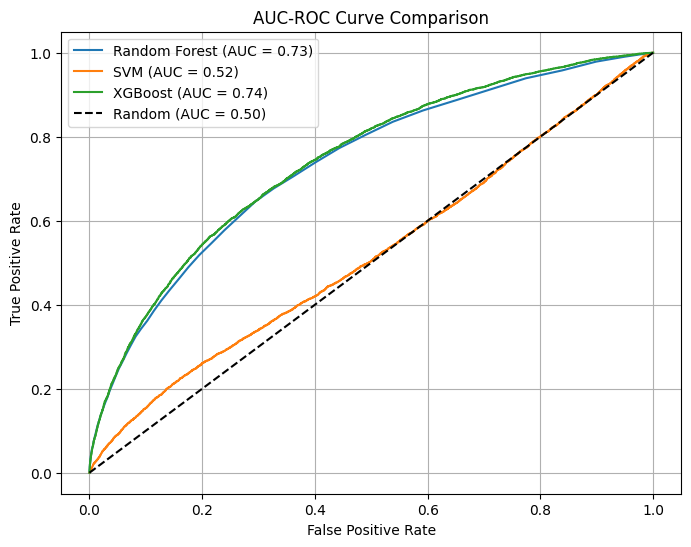

In [12]:
# Predict probabilities for AUC-ROC
rf_probs = rf.predict_proba(X_test)[:, 1]
svm_probs = svm.predict_proba(X_test)[:, 1]
xgb_probs = xgb.predict_proba(X_test)[:, 1]

# Calculate AUC scores
rf_auc = roc_auc_score(y_test, rf_probs)
svm_auc = roc_auc_score(y_test, svm_probs)
xgb_auc = roc_auc_score(y_test, xgb_probs)

# Print AUC Scores
print(f"Random Forest AUC: {rf_auc:.3f}")
print(f"SVM AUC: {svm_auc:.3f}")
print(f"XGBoost AUC: {xgb_auc:.3f}")

# Plot ROC Curves
rf_fpr, rf_tpr, _ = roc_curve(y_test, rf_probs)
svm_fpr, svm_tpr, _ = roc_curve(y_test, svm_probs)
xgb_fpr, xgb_tpr, _ = roc_curve(y_test, xgb_probs)

plt.figure(figsize=(8,6))
plt.plot(rf_fpr, rf_tpr, label=f'Random Forest (AUC = {rf_auc:.2f})')
plt.plot(svm_fpr, svm_tpr, label=f'SVM (AUC = {svm_auc:.2f})')
plt.plot(xgb_fpr, xgb_tpr, label=f'XGBoost (AUC = {xgb_auc:.2f})')
plt.plot([0, 1], [0, 1], 'k--', label='Random (AUC = 0.50)')
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("AUC-ROC Curve Comparison")
plt.legend()
plt.grid(True)
plt.show()


In [ ]:
!pip  install nbformat>=4.2.0



[notice] A new release of pip is available: 24.3.1 -> 25.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [ ]:
import pandas as pd
import numpy as np
import ipywidgets as widgets
from IPython.display import display, clear_output
import plotly.graph_objects as go
import pickle

# ======================
# 1. LOAD TRAINED MODELS
# ======================
print("🔄 Loading trained models...")

# Load the trained Random Forest model
with open('rf_model.pkl', 'rb') as f:
    rf_model = pickle.load(f)

# Load the label encoders
with open('label_encoders.pkl', 'rb') as f:
    le_dict = pickle.load(f)

# Get feature names used during training
model_features = rf_model.feature_names_in_

# ======================
# 2. INPUT FORM
# ======================
print("✅ Models loaded successfully!")
print("\n🛠️ LOAN RISK ASSESSMENT TOOL")
print("Enter applicant details:")

# Create interactive form with custom styles
style = {'description_width': 'initial'}

age = widgets.IntSlider(value=30, min=18, max=70, description="Age:", style=style)
income = widgets.IntSlider(value=50000, min=20000, max=200000, step=5000, description="Income:", style=style)
loan_amount = widgets.IntSlider(value=100000, min=5000, max=500000, step=5000, description="Loan Amount:", style=style)
credit_score = widgets.IntSlider(value=650, min=300, max=850, description="Credit Score:", style=style)
months_employed = widgets.IntSlider(value=36, min=0, max=120, description="Months Employed:", style=style)
num_credit_lines = widgets.IntSlider(value=2, min=1, max=10, description="Credit Lines:", style=style)
interest_rate = widgets.FloatSlider(value=7.5, min=0, max=30, step=0.1, description="Interest Rate:", style=style)
loan_term = widgets.IntSlider(value=36, min=12, max=120, step=12, description="Loan Term (months):", style=style)
dti_ratio = widgets.FloatSlider(value=0.4, min=0, max=1, step=0.01, description="DTI Ratio:", style=style)

employment = widgets.Dropdown(
    options=['Full-time', 'Part-time', 'Unemployed', 'Self-employed'],
    value='Full-time',
    description='Employment:',
    style=style
)

education = widgets.Dropdown(
    options=['High School', 'Bachelor', 'Master', 'PhD'],
    value='Bachelor',
    description='Education:',
    style=style
)

marital_status = widgets.Dropdown(
    options=['Single', 'Married', 'Divorced', 'Widowed'],
    value='Single',
    description='Marital Status:',
    style=style
)

has_mortgage = widgets.Dropdown(
    options=['Yes', 'No'],
    value='No',
    description='Has Mortgage:',
    style=style
)

has_dependents = widgets.Dropdown(
    options=['Yes', 'No'],
    value='No',
    description='Has Dependents:',
    style=style
)

loan_purpose = widgets.Dropdown(
    options=['Home', 'Auto', 'Business', 'Education', 'Other'],
    value='Home',
    description='Loan Purpose:',
    style=style
)

has_cosigner = widgets.Dropdown(
    options=['Yes', 'No'],
    value='No',
    description='Has Co-Signer:',
    style=style
)

submit_btn = widgets.Button(description="Assess Risk", button_style='success')

# ======================
# 3. RESULTS DISPLAY
# ======================
output = widgets.Output()

def update_bar_graph(risk):
    bar_graph = go.Figure(go.Bar(
        x=[risk],
        y=['Risk Score'],
        orientation='h',
        marker=dict(color='red' if risk > 70 else 'orange' if risk > 30 else 'green')
    ))

    bar_graph.update_layout(
        title=f"Default Risk: {risk}%",
        xaxis=dict(range=[0, 100], title="Risk Percentage"),
        yaxis=dict(showticklabels=False),
        showlegend=False
    )
    
    bar_graph.show()

# ======================
# 4. PREDICTION LOGIC
# ======================
def on_submit_clicked(b):
    with output:
        clear_output()
        
        # Prepare input data
        input_data = pd.DataFrame({
            'Age': [age.value],
            'Income': [income.value],
            'LoanAmount': [loan_amount.value],
            'CreditScore': [credit_score.value],
            'MonthsEmployed': [months_employed.value],
            'NumCreditLines': [num_credit_lines.value],
            'InterestRate': [interest_rate.value],
            'LoanTerm': [loan_term.value],
            'DTIRatio': [dti_ratio.value],
            'Education': [education.value],
            'EmploymentType': [employment.value],
            'MaritalStatus': [marital_status.value],
            'HasMortgage': [has_mortgage.value],
            'HasDependents': [has_dependents.value],
            'loan_purpose': [loan_purpose.value],
            'HasCoSigner': [has_cosigner.value]
        })
        
        # Add a column for LoanID (this is a placeholder)
        input_data['LoanID'] = 0  # Placeholder value for the LoanID column

        # Encode categorical variables using the loaded label encoders
        for col in input_data.select_dtypes(include='object').columns:
            if col in le_dict:
                le = le_dict[col]
                input_data[col] = input_data[col].apply(
                    lambda x: x if x in le.classes_ else le.classes_[0]
                )
                input_data[col] = le.transform(input_data[col])

        # Ensure the input data columns are in the same order as the model was trained
        input_data = input_data[model_features]

        # Predict
        proba = rf_model.predict_proba(input_data)[0][1]
        risk_score = round(proba * 100, 2)
        
        # Display results
        update_bar_graph(risk_score)
        
        print("\n📊 KEY RISK FACTORS:")
        feature_imp = pd.Series(rf_model.feature_importances_, index=input_data.columns)
        top_3 = feature_imp.sort_values(ascending=False)[:3]
        
        for feature, importance in top_3.items():
            print(f"• {feature}: {importance * 100:.1f}% impact")
            
        print("\n🎯 RECOMMENDATION:")
        if risk_score < 30:
            print("✅ LOW RISK - Safe to approve")
        elif risk_score < 70:
            print("⚠️ MEDIUM RISK - Requires review")
        else:
            print("❌ HIGH RISK - Recommend rejection")

submit_btn.on_click(on_submit_clicked)

# ======================
# 5. DISPLAY THE UI
# ======================
form = widgets.VBox([
    widgets.HTML("<h3 style='color: #4CAF50;'>Basic Information</h3>"),
    widgets.HBox([age, income]),
    widgets.HBox([loan_amount, credit_score]),
    widgets.HBox([months_employed, num_credit_lines]),
    widgets.HBox([interest_rate, dti_ratio]),
    loan_term,
    
    widgets.HTML("<h3 style='color: #4CAF50;'>Additional Details</h3>"),
    widgets.HBox([employment, education]),
    widgets.HBox([marital_status, has_mortgage]),
    widgets.HBox([has_dependents, loan_purpose]),
    has_cosigner,
    
    submit_btn
])

# Apply custom CSS styles to the form
form.layout.align_items = 'center'
form.layout.padding = '20px'
form.layout.border = '2px solid #4CAF50'
form.layout.border_radius = '10px'
form.layout.background_color = '#f9f9f9'

display(form, output)


🔄 Loading trained models...
✅ Models loaded successfully!

🛠️ LOAN RISK ASSESSMENT TOOL
Enter applicant details:


Output()